# Analyze global fit results

In [10]:
import numpy as np
import sys
import os
import subprocess
import matplotlib as mpl
from matplotlib import pyplot as plt
from copy import deepcopy

mpl.rcParams["figure.dpi"] = 150
mpl.rcParams["savefig.dpi"] = 600


sys.path.append(os.path.abspath("/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/"))

# Enable autoreload extension
%load_ext autoreload

# Reload only the utils package before running a cell
%autoreload 1
%aimport fit_utils
%aimport fit_utils.utils
%aimport fit_utils.pullplots
%aimport fit_utils.parser
%aimport fit_utils.EFT_matching
%aimport find_1sigma_WCs

import fit_utils.utils as utils
import fit_utils.pullplots as pullplots
import fit_utils.parser as parser
import fit_utils.EFT_matching as EFT_matching

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload



Finding configuration files for the observables

Setting configuration files for scenario: . model spec: fits_small_priors_updated_lumi_strict
Files considered:
- Globalfits/AllOps/d6Ops_corr.conf

Reading configuration files for observables
Reading configuration file ./SM_fit/./Globalfits/AllOps/d6Ops_corr.conf
Found 29 observables



{'SM_fit': {'.': {'fits_small_priors_updated_lumi_strict': ['CW_corr', 'CHG_corr', 'CHW_corr', 'CHB_corr', 'CHWB_corr', 'CHD_corr', 'CHbox_corr', 'CHL1_11_corr', 'CHL1_22_corr', 'CHL1_33_corr', 'CHL3_11_corr', 'CHL3_22_corr', 'CHL3_33_corr', 'CHe_11_corr', 'CHe_22_corr', 'CHe_33_corr', 'CHQ1_11_corr', 'CHQ1_33_corr', 'CHQ3_11_corr', 'CHu_11_corr', 'CHd_11_corr', 'CHd_33_corr', 'CeH_22r_corr', 'CeH_33r_corr', 'CuH_22r_corr', 'CuH_33r_corr', 'CdH_33r_corr', 'CLL_1221_corr', 'CH_corr']}}}

Reading fit results
Reading file: ./SM_fit/./results_fits_small_priors_updated_lumi_strict/Observables/Statistics.txt

Parameter dictionary: 
{'SM_fit': {'.': {'fits_sma

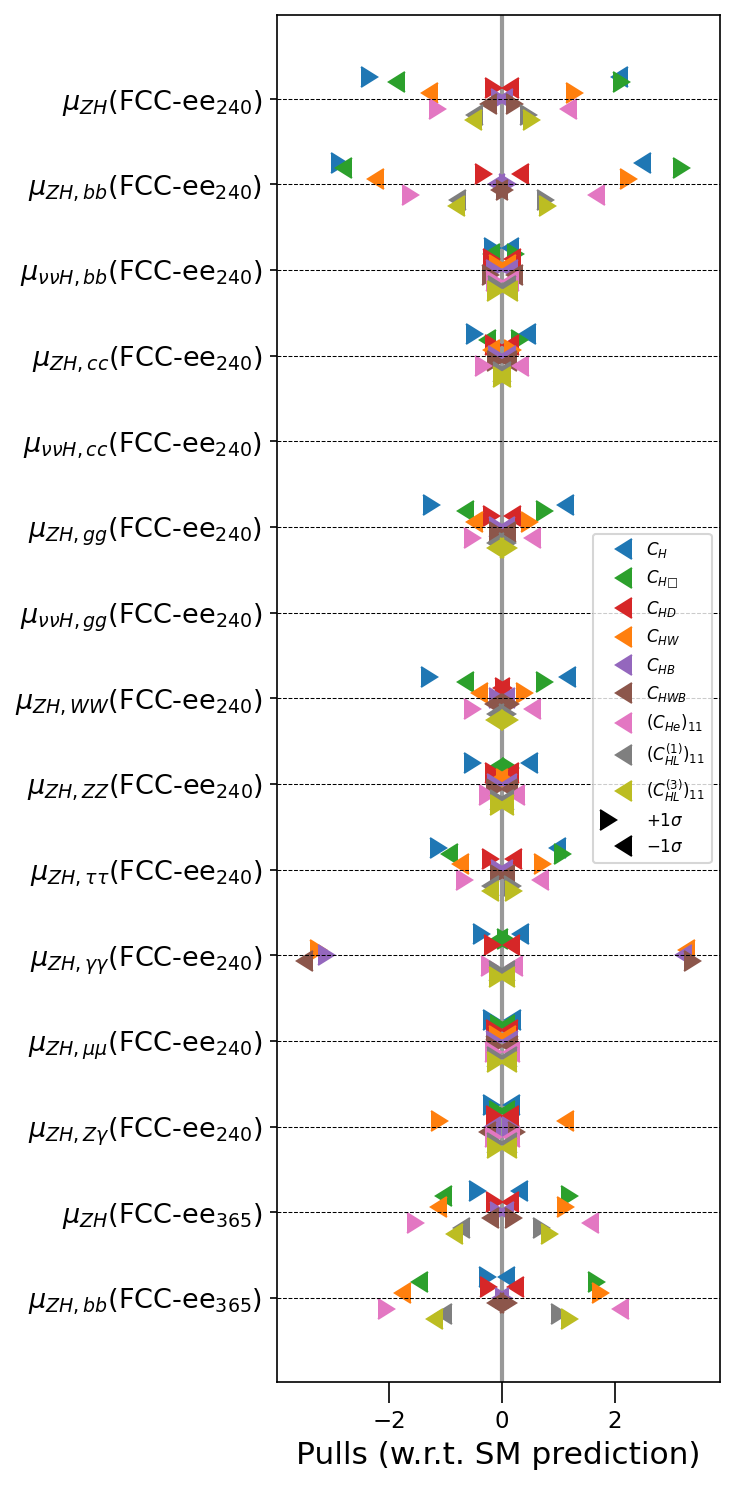

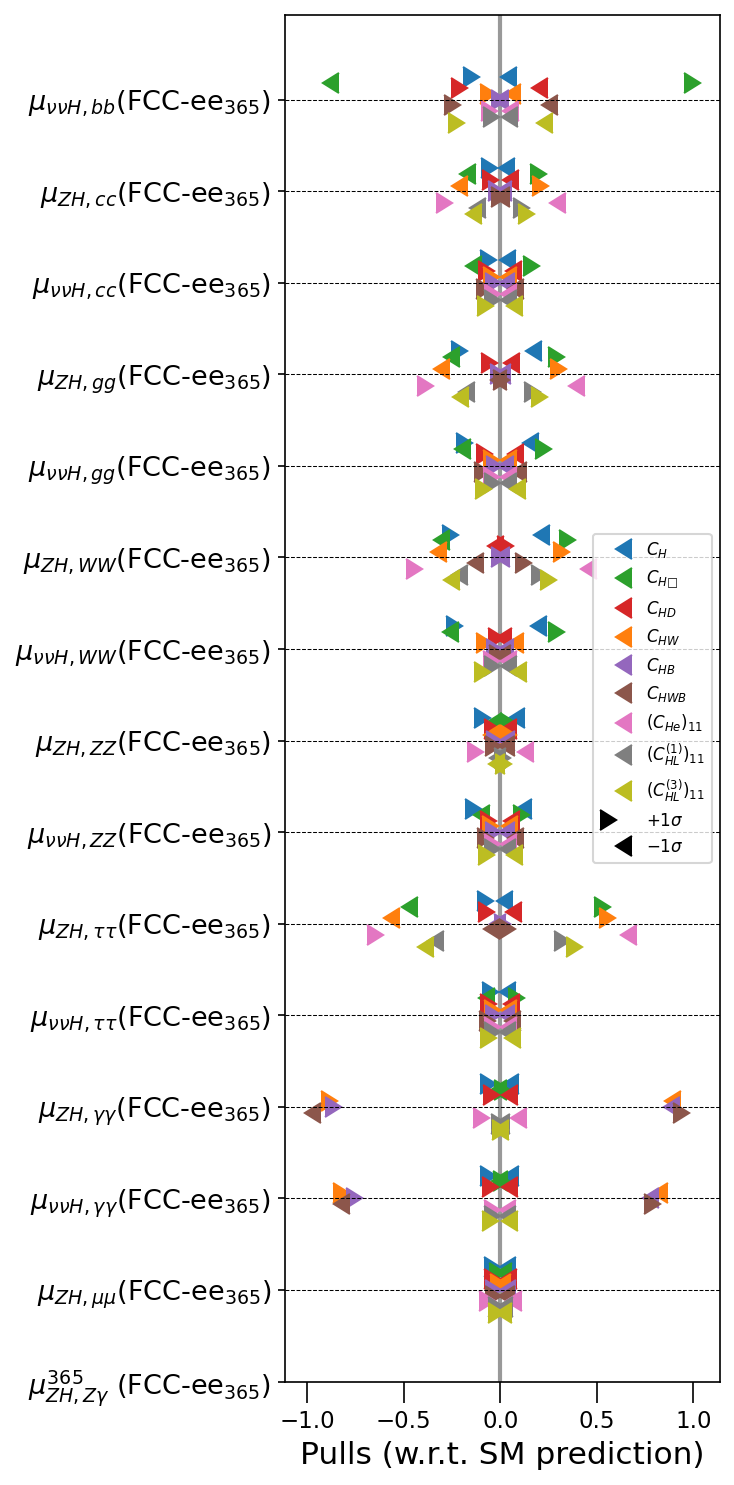

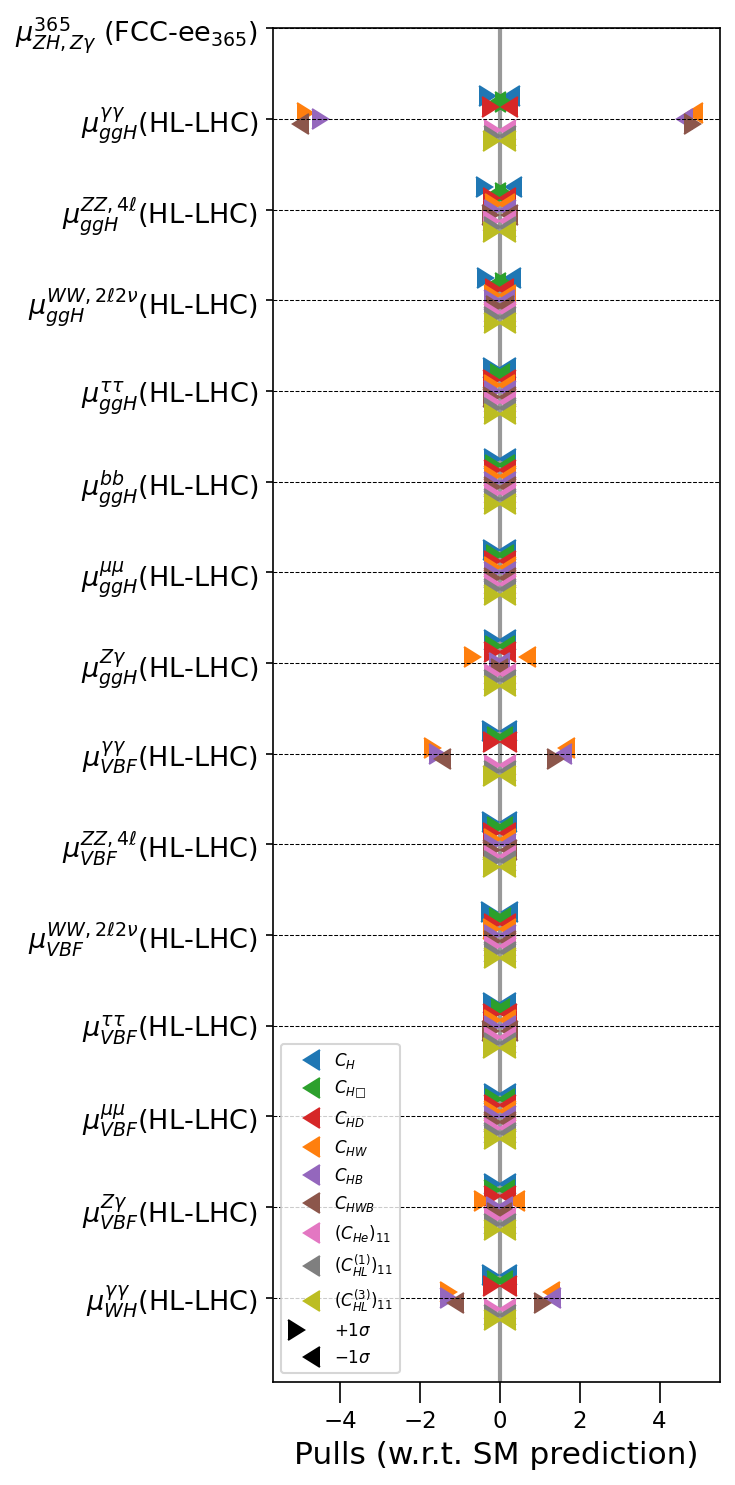

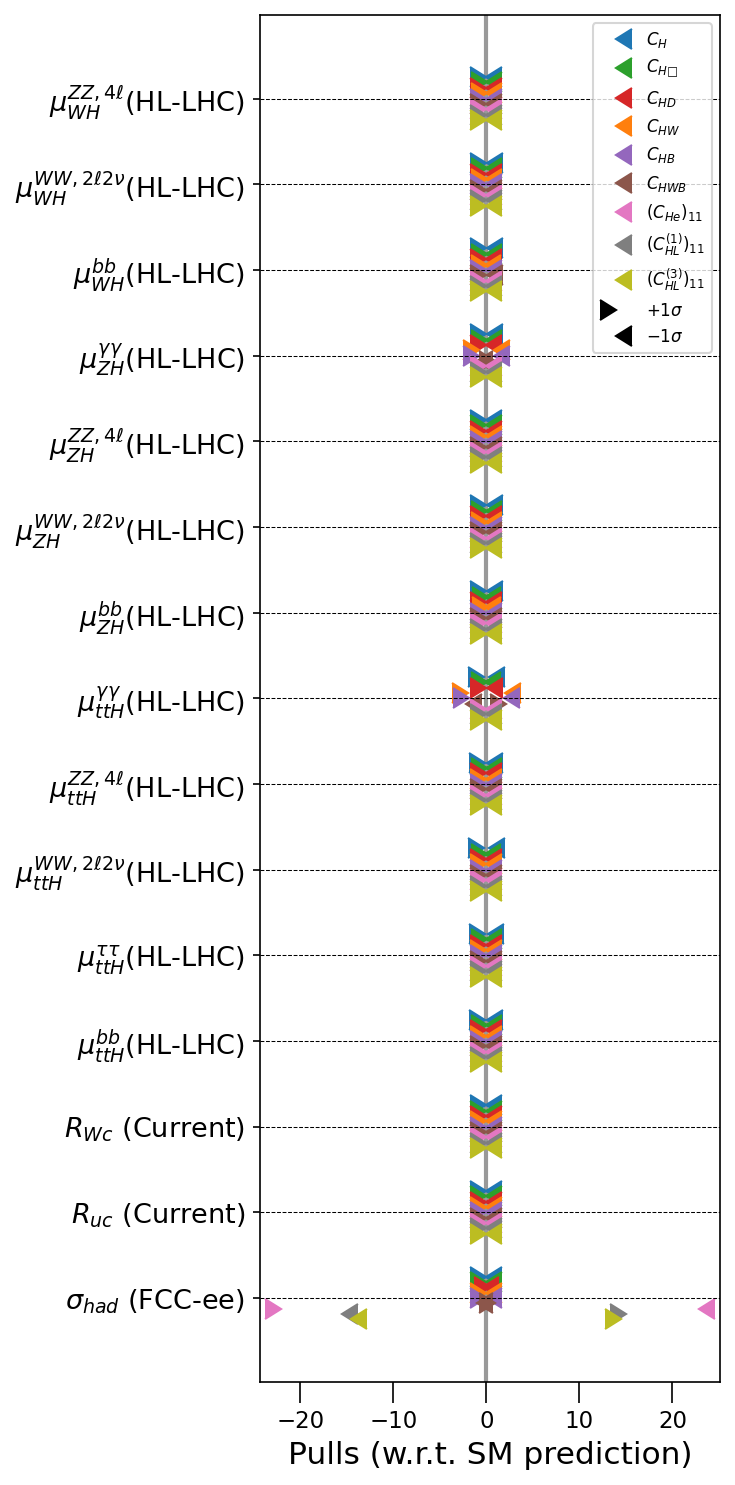

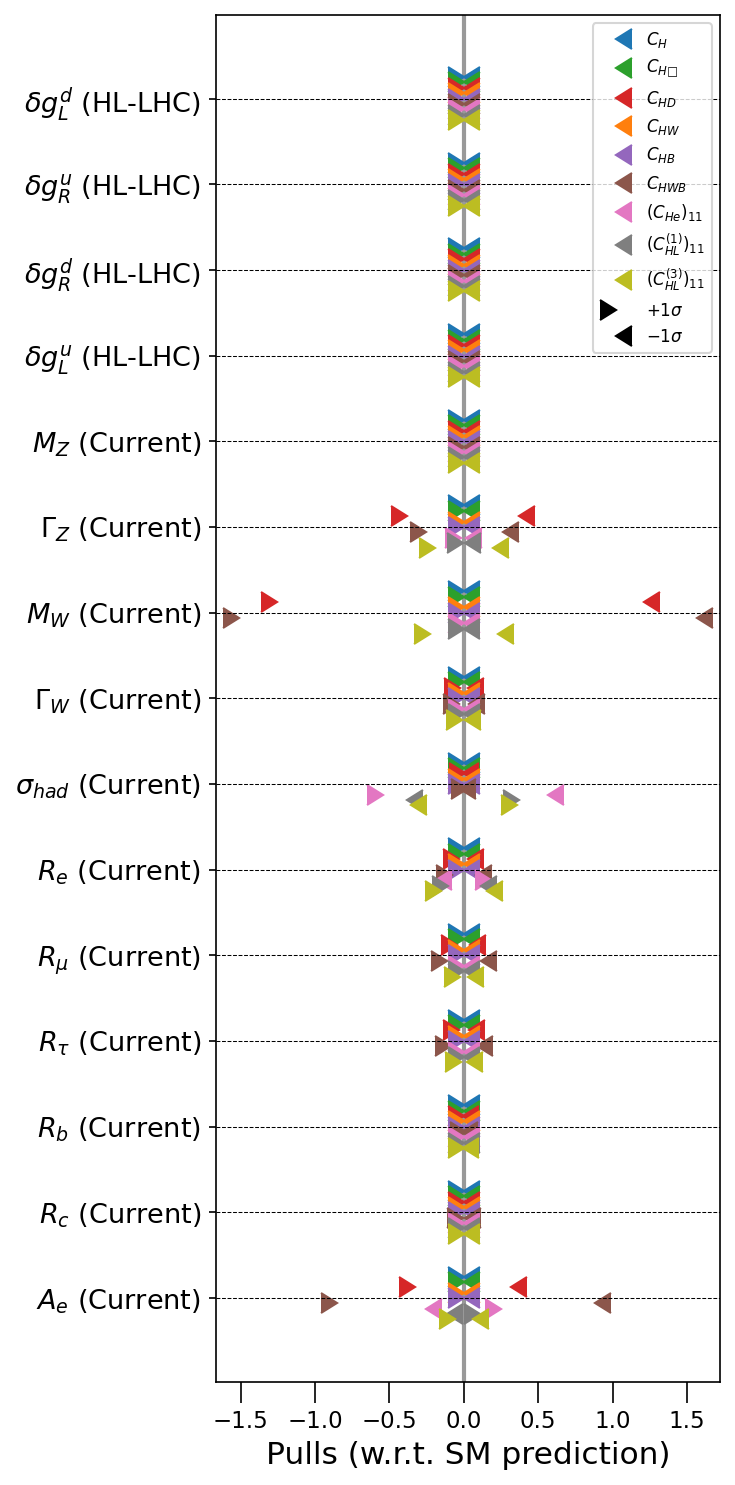

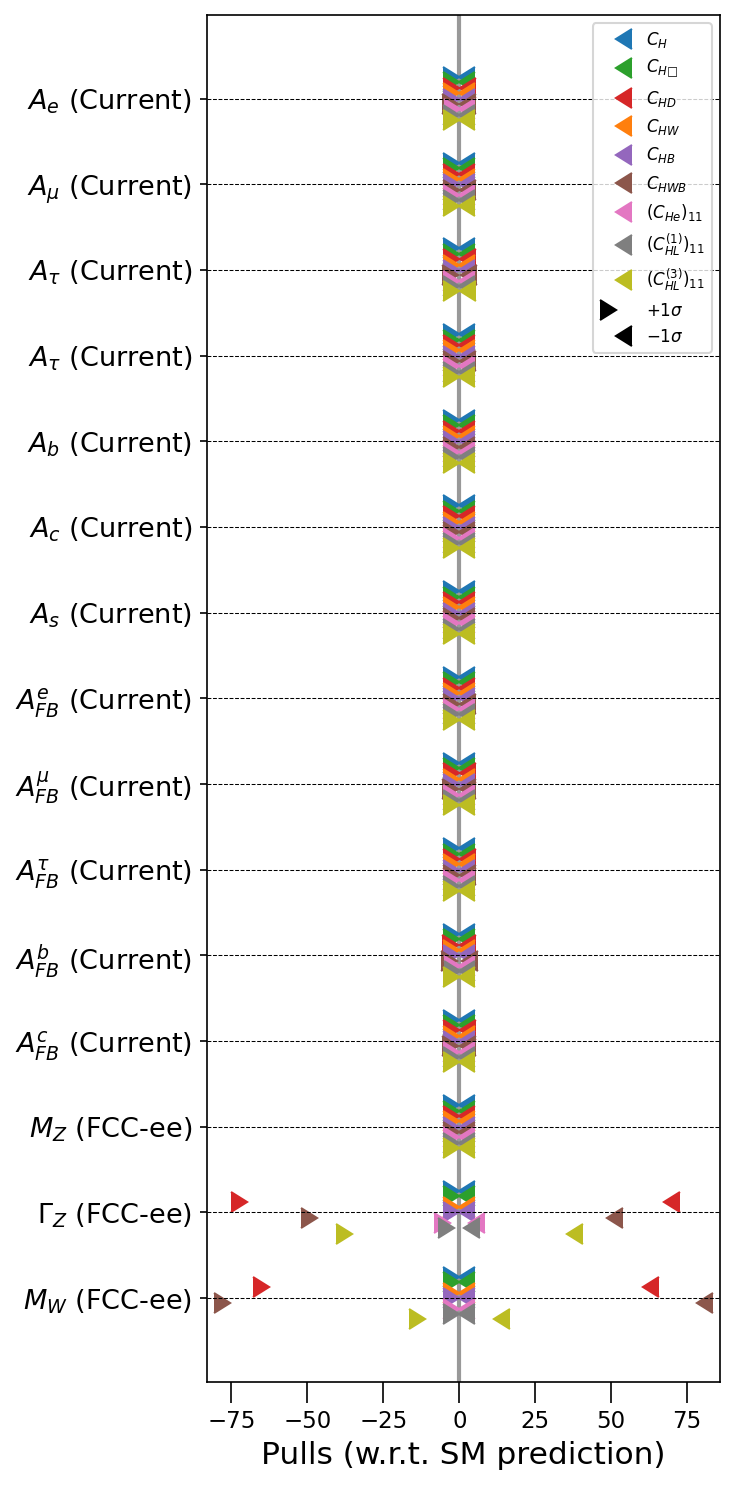

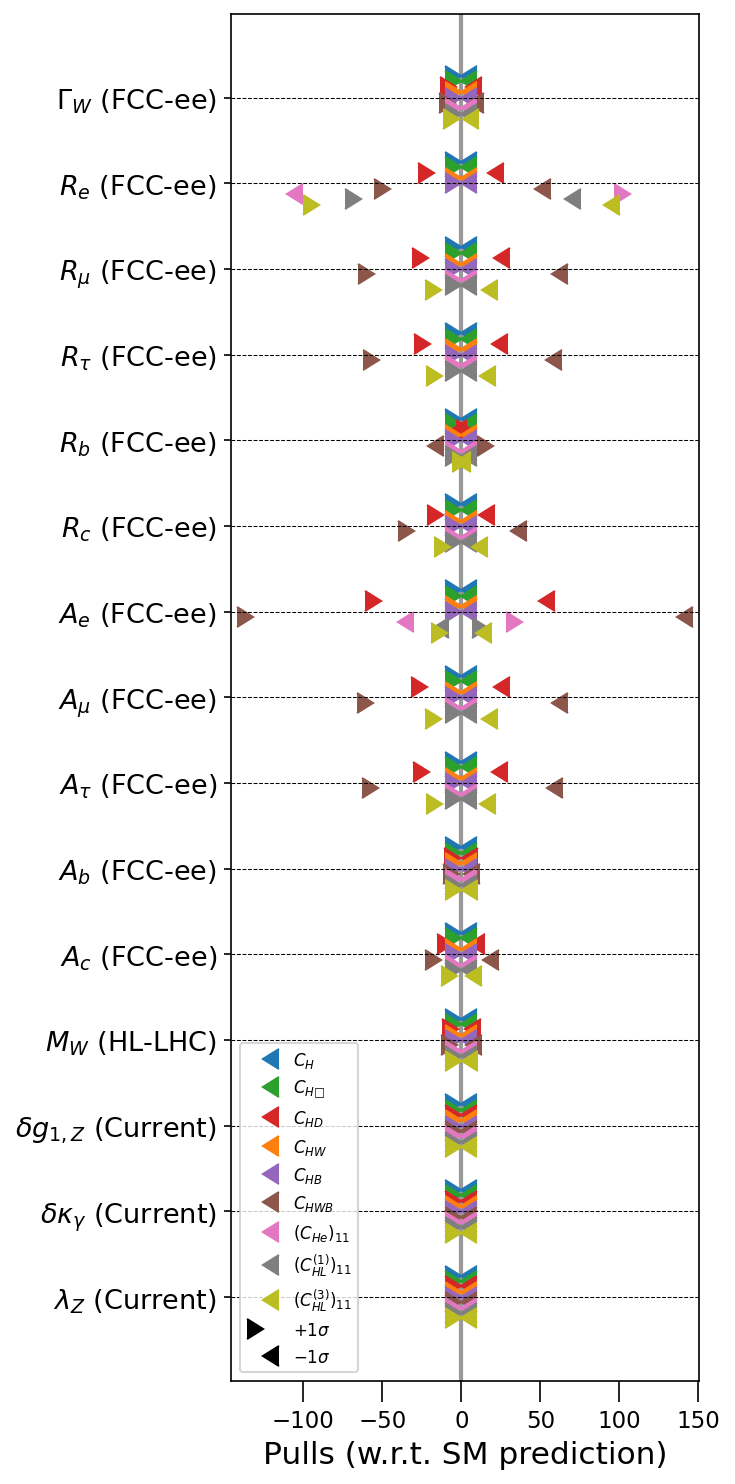

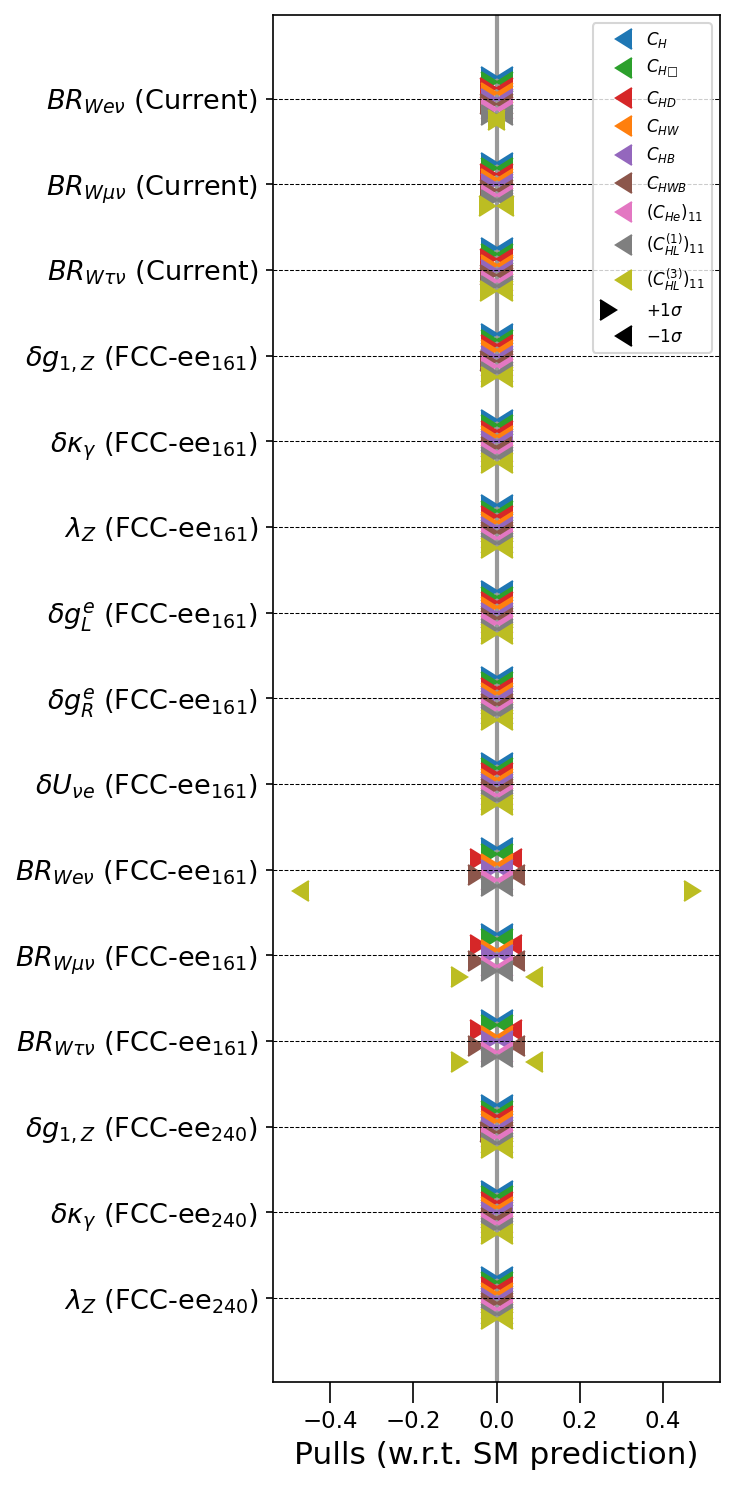

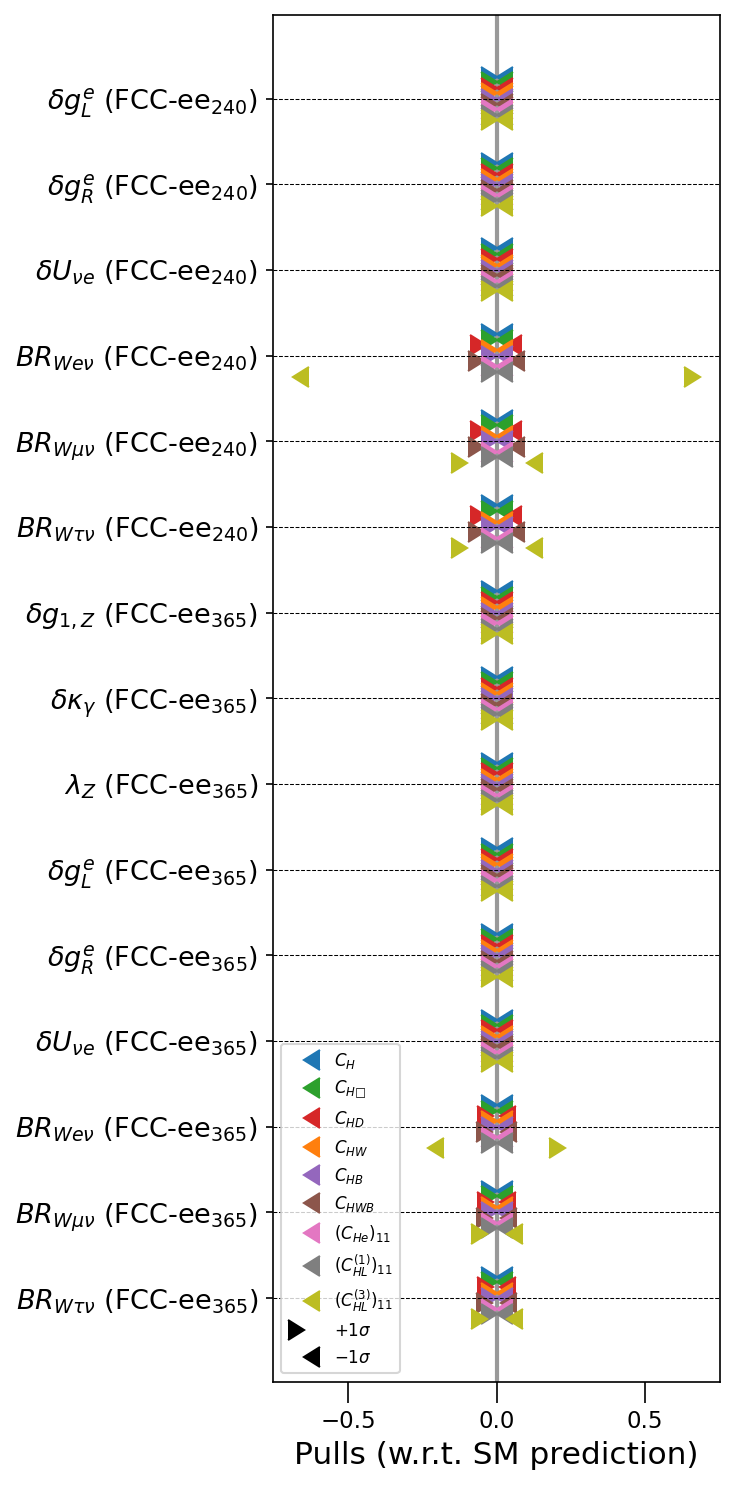

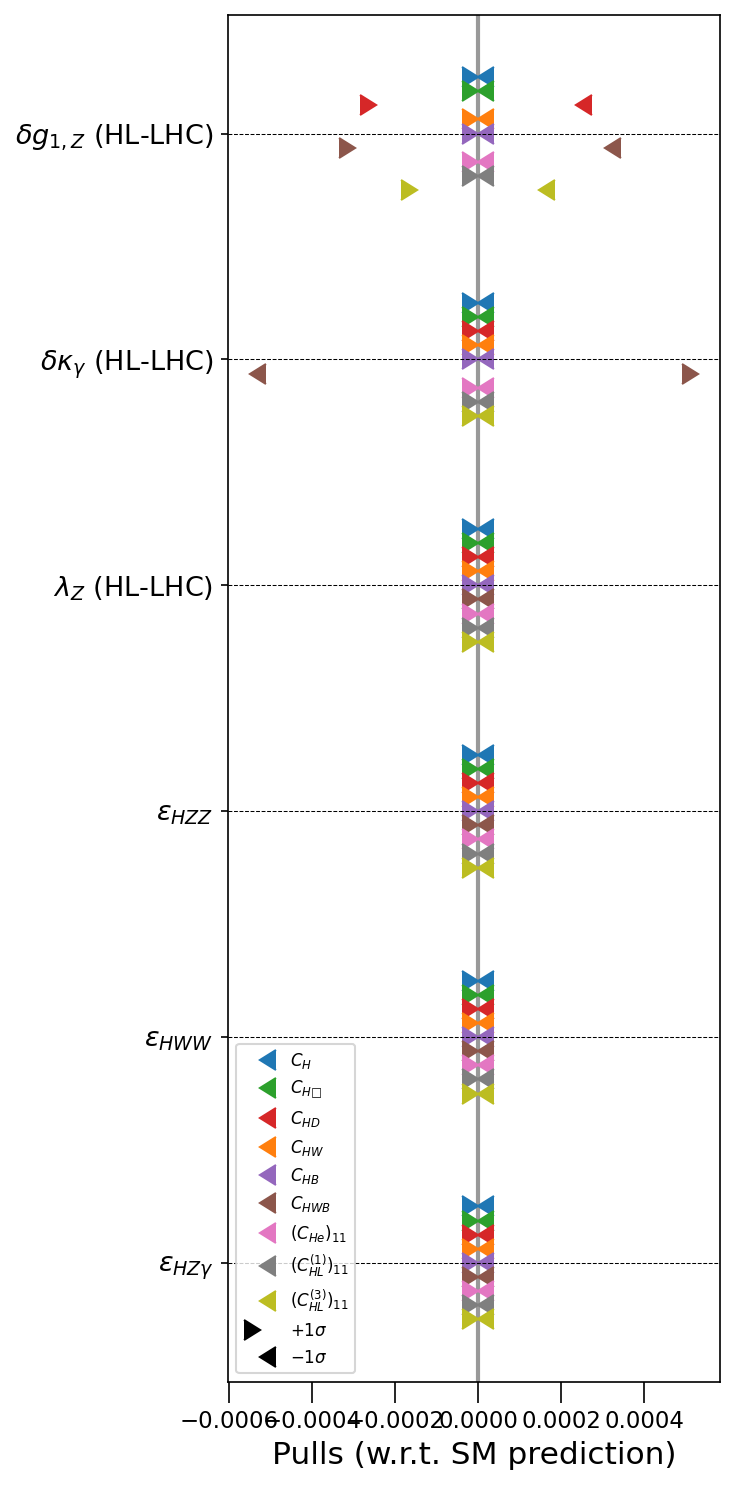

In [11]:
from fit_utils.parser import find_tex_label_par
from find_1sigma_WCs import find_1sigma_WCs

# WCs = ["CH", "CHbox", "CHD", "CHW", "CHG", "CHB", "CHWB", "CuH_33r"]
# WCs = ["CH", "CHbox", "CHD", "CHW", "CHG", "CHB", "CHWB",]
WCs = ["CH", "CHbox", "CHD", "CHW", "CHB", "CHWB", "CHe_11", "CHL1_11", "CHL3_11"]
# WCs = ["CH", "CuH_33r"]

# WC_labels = [ find_tex_label_par(None, wc) + r"$=1$" for wc in WCs ]
WC_labels = [ find_tex_label_par(None, wc) for wc in WCs ]


working_dir = "."
results_dir = "fits_small_priors_updated_lumi_strict"
BPs = ["Config_Files", ]
# model_specs = {"." : [".", ]}
# specs = ['fits_small_priors_strict', ]
specs = ['fits_small_priors_updated_lumi_strict', ]
model_specs = {"." : specs}
scenarios = model_specs.keys()
file_suffix = "_all"
x_range_min = None
x_range_max = None

# WC_values = np.linspace(0.01, 0.01, 1)
WC_values = find_1sigma_WCs(WCs, model_specs)
WC_values = np.array([[WC_values[wc+ "_low"], WC_values[wc+ "_high"]] for wc in WCs])
n_WC_values = WC_values.shape[1]


nvar_per_plot=15
figsize=(5, 10)
legend_loc="best"
log_scale=False
colors = ["tab:blue", "tab:green", "tab:red", "tab:orange", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]
# plot_titles = [""]
plot_dir = f"{working_dir}/plots/"

plot_titles = { 
    BP : {
        scenario : ""
        for scenario in scenarios
    } 
    for BP in BPs
}


pullplots.generate_pull_plots_obs(
    BPs,
    model_specs,
    working_dir,
    results_dir,
    model_specs_labels=None,
    plot_titles=plot_titles,
    model="SM_updated_lumi",
    only_obs=None,
    skip_obs=None,
    colors=colors,
    show_plots=True,
    nvar_per_plot=nvar_per_plot,
    only_higgs_fccee_obs=False,
    compare_with_SM=False,
    WC_list_for_prediction_pulls=WCs,
    figsize=figsize,
    legend_loc=legend_loc,
    file_suffix=file_suffix,
    save_fig=False,
)


Finding configuration files for the observables

Reading configuration files for observables
Reading configuration file ./Config_Files/./ObservablesEW_updated_lumi.conf
Reading configuration file ./Config_Files/./ObservablesEW_Current_SM_noLFU.conf
Reading configuration file ./Config_Files/./ObservablesEW_FCCee_Zpole_SM_updated_lumi.conf
Reading configuration file ./Config_Files/./ObservablesEW_FCCee_WW_SM_updated_lumi.conf
Reading configuration file ./Config_Files/./ObservablesEW_HLLHC.conf
Reading configuration file ./Config_Files/./ObservablesHiggs_updated_lumi.conf
Reading configuration file ./Config_Files/./ObservablesHiggs_FCCee_240_SM_updated_lumi.conf
Reading configuration file ./Config_Files/./ObservablesHiggs_FCCee_365_updated_lumi.conf
Reading configuration file ./Config_Files/./ObservablesHiggs_HLLHC_SM.conf
Reading configuration file ./Config_Files/./ObservablesVV.conf
Reading configuration file ./Config_Files/./aTGC_observables_Current.conf
Reading configuration file ./C

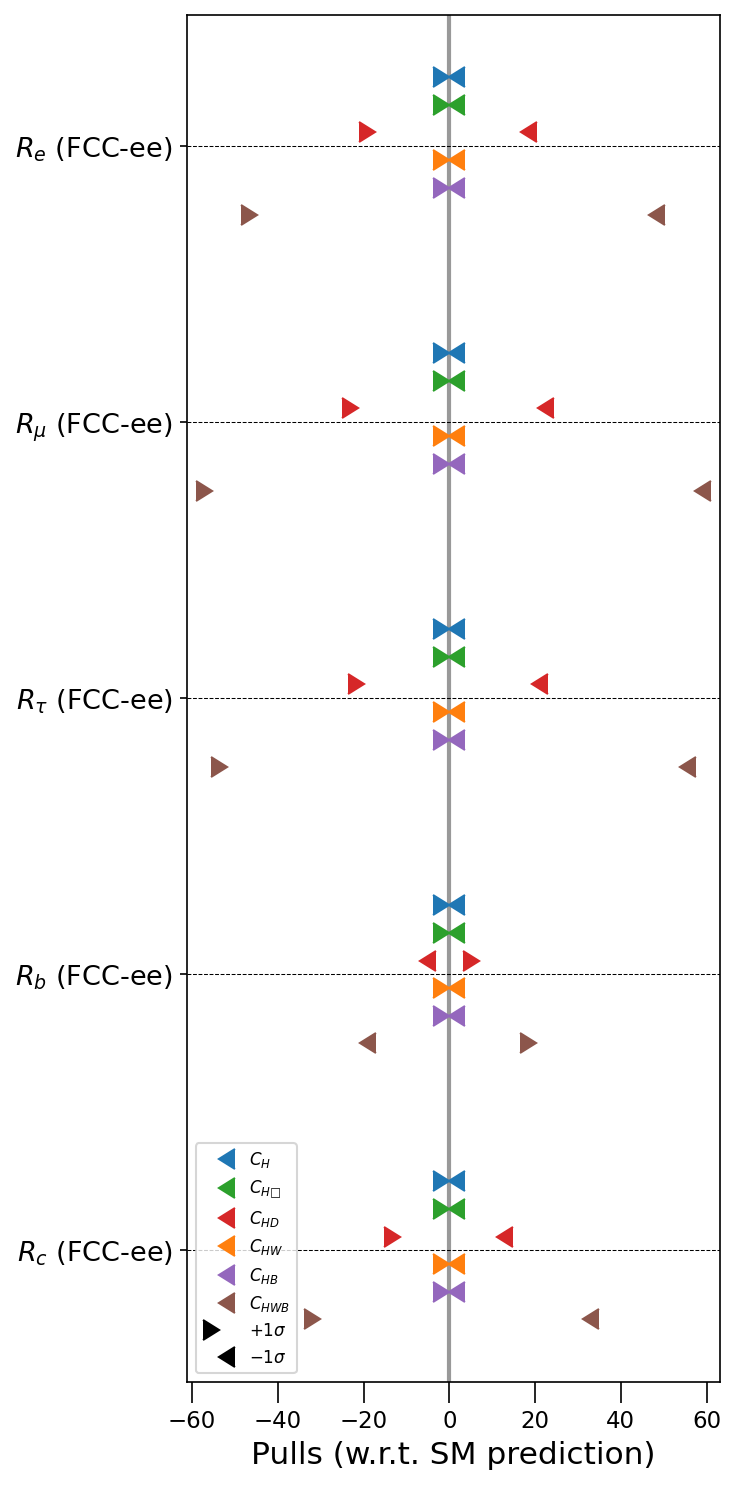

In [14]:
WCs = ["CH", "CHbox", "CHD", "CHW", "CHB", "CHWB"]
# WCs = ["CH", "CHbox", "CHD", "CHW", "CHB", "CHWB", "CHe_11", "CHL1_11", "CHL3_11"]
file_suffix = "_select"
only_obs = ["Relectron_FCCee", "Rmuon_FCCee", "Rtau_FCCee", "Rbottom_FCCee", "Rcharm_FCCee",]

pullplots.generate_pull_plots_obs(
    BPs,
    model_specs,
    working_dir,
    results_dir,
    model_specs_labels=None,
    plot_titles=plot_titles,
    model="SM_updated_lumi",
    only_obs=only_obs,
    skip_obs=None,
    colors=colors,
    show_plots=True,
    nvar_per_plot=nvar_per_plot,
    only_higgs_fccee_obs=False,
    compare_with_SM=False,
    WC_list_for_prediction_pulls=WCs,
    figsize=figsize,
    legend_loc=legend_loc,
    file_suffix=file_suffix,
    save_fig=True,
)

## Correlations

Reading file: ./SM_fit/./results_fits_small_priors_strict/Observables/Statistics.txt
Found 29 observables in the correlation matrix




Producing plot for scenario ., model specification fits_small_priors_strict, BP SM_fit
Total number of WCs considered for the plot: 9
WCs considered for the plot: ['CH', 'CHbox', 'CHD', 'CHW', 'CHB', 'CHWB', 'CHe_11', 'CHL1_11', 'CHL3_11']


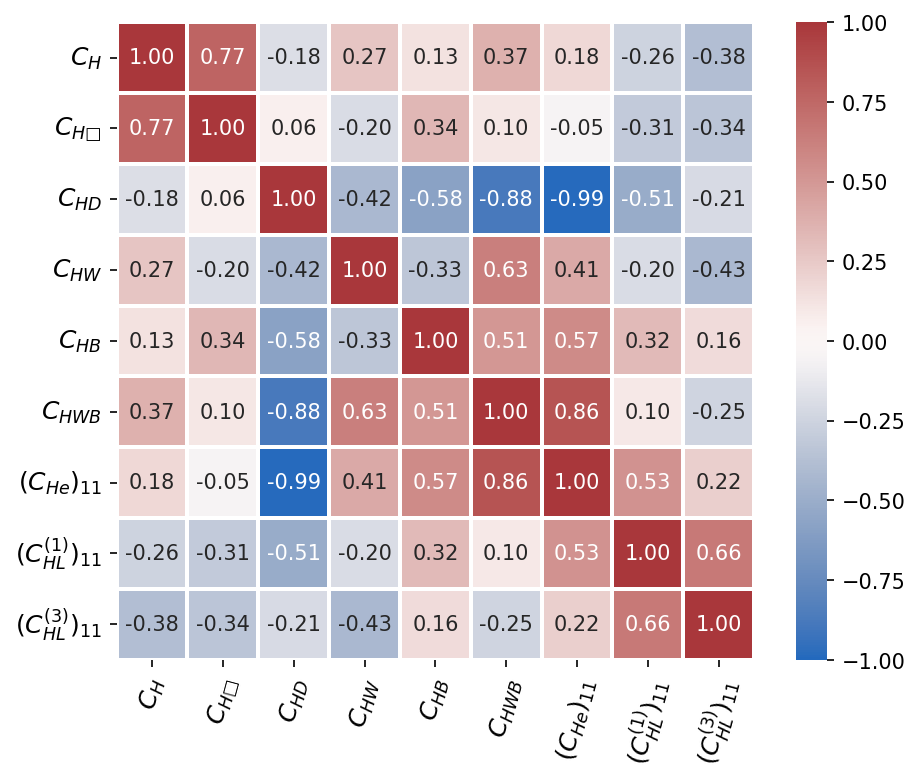

In [37]:
BPs = ["SM_fit", ]
results_dirs = specs
WCs = ["CH", "CHbox", "CHD", "CHW", "CHB", "CHWB", "CHe_11", "CHL1_11", "CHL3_11"]
pullplots.generate_WC_corr_matrix_plot(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dirs=results_dirs,
    WC_names=WCs,
    plot_titles=None,
    show_plots=True,
    figsize=(6.5, 5.3),
    file_suffix="_all",
    save_fig=True,
)

Reading file: ./SM_fit/./results_fits_small_priors_strict/Observables/Statistics.txt
Found 29 observables in the correlation matrix




Producing plot for scenario ., model specification fits_small_priors_strict, BP SM_fit
Total number of WCs considered for the plot: 6
WCs considered for the plot: ['CH', 'CHbox', 'CHD', 'CHW', 'CHB', 'CHWB']


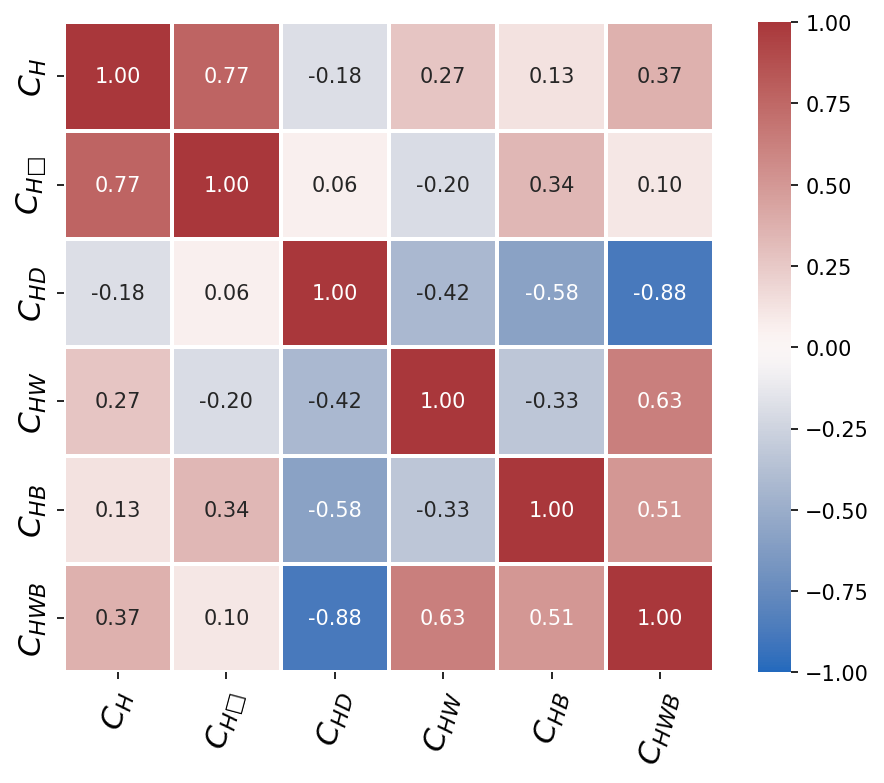

In [38]:
BPs = ["SM_fit", ]
results_dirs = specs
WCs = ["CH", "CHbox", "CHD", "CHW", "CHB", "CHWB",]
pullplots.generate_WC_corr_matrix_plot(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dirs=results_dirs,
    WC_names=WCs,
    plot_titles=None,
    show_plots=True,
    figsize=(6.5, 5.3),
    file_suffix="_select",
    labelsize=15,
    save_fig=True,
)